# Flujo de trabajo para usar la API de OpenAI para análisis de datos de Fauna de Tenerife

Datos de tortugas marinas varadas del Centro de Recuperación de Fauna Silvestre (CRFS) de La Tahonilla.

Tabla de contenidos:

- [OPENAI KEY](#openai-api-key)
- [Cargar dataset de Tortugas Marinas del CRFS de La Tahonilla](#cargar-algunos-datos-de-la-demo-del-dataset-de-tortugas-marinas-del-crfs-la-tahonilla)
- [Funciones](#funciones)
- [Extracción de datos del campo de observaciones](#extracción-de-datos-del-campo-de-observaciones)
- [Extracción de datos del campo del LUGAR](#extracción-de-datos-del-campo-del-lugar) 

In [1]:
from openai import OpenAI
import pandas as pd
import numpy as np
import geopandas as gpd
import json
from tqdm import tqdm
from shapely.geometry import Point

## OPENAI API key

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()  # busca automáticamente el archivo .env en el directorio actual

api_key = os.getenv("OPENAI_API_KEY")

## Cargar algunos datos de la Demo del Dataset de Tortugas Marinas del CRFS La Tahonilla

Los datos están en la carpeta "demo_datasets", el archivo es [demo_tortugas.csv](../demo_datasets/demo_tortugas.csv)

In [3]:
dataset = pd.read_csv("../demo_datasets/demo_tortugas.csv", sep=";").head()
print(dataset)

   id             ficha          especie nombre.especie  fecha_orig  \
0   1  1892 - 1977-1990  Caretta caretta   Tortuga Boba  18/04/1990   
1   2  1868 - 1977-1990  Caretta caretta   Tortuga Boba  14/11/1989   
2   3  9537 - 1998-2010  Caretta caretta   Tortuga Boba  02/12/2010   
3   4  9521 - 1998-2010  Caretta caretta   Tortuga Boba  15/11/2010   
4   5  9436 - 1998-2010  Caretta caretta   Tortuga Boba  29/09/2010   

        fecha  anio         mes   estacion               lugar_orig  ...  \
0  18/04/1990  1990       Abril  Primavera         Rambla de castro  ...   
1  14/11/1989  1989   Noviembre      Otoño                      NaN  ...   
2  02/12/2010  2010   Diciembre   Invierno  CANDELARIA - CANDELARIA  ...   
3  15/11/2010  2010   Noviembre      Otoño             Puerto Colón  ...   
4  29/09/2010  2010  Septiembre      Otoño         EL PORIS - ARICO  ...   

                                           fmt_lugar               muni  \
0  Calle Castro, 38611, Granadilla de Abo

## Funciones

### Función y lectura del texto que se usará como prompt

In [4]:
# Función para leer el contenido de un archivo prompt:
def load_prompt(file_path):
    with open(file_path, 'r') as file:
        return file.read()

In [5]:
def extract_data_from_text(text):
    # Load system content and user content
    #system_content = load_prompt('prompts/llm_system_promt.txt')
    user_content = f"Text: {text}"

    # Initialize the OpenAI API client
    client = OpenAI()

    # Make a request to the OpenAI API to generate a chat completion
    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": system_content
            },
            {
                "role": "user",
                "content": user_content
            }
        ],
        #model="gpt-3.5-turbo",
        model="gpt-4.1",
        temperature=0.1,
        max_tokens=4096,
        top_p=0.5,
        response_format={ "type": "json_object" }
    )

    # Extract the completion result and token usage information from the response
    completion = chat_completion.choices[0].message.content
    result = json.loads(completion)
    prompt_tokens_used = chat_completion.usage.prompt_tokens
    completion_tokens_used = chat_completion.usage.completion_tokens

    return result, prompt_tokens_used, completion_tokens_used

In [6]:
## Función para extraer datos de un dataframe
def extract_data_from_df(df): 
    results = []
    total_prompt_tokens_used = 0
    total_completion_tokens_used = 0

    for text in tqdm(df['text'], desc="Processing texts"):
        result, prompt_tokens_used, completion_tokens_used = extract_data_from_text(text)
        results.append(result)

        total_prompt_tokens_used += prompt_tokens_used
        total_completion_tokens_used += completion_tokens_used

    return pd.DataFrame(results)

# Extracción de datos del campo de OBSERVACIONES

**Texto usado en el siguiente enlace**: en la carpeta *"prompts"* [llm_system_promt.txt](../prompts/llm_system_promt.txt)

In [7]:
system_content = load_prompt("../prompts/llm_system_promt.txt")

## Ejemplo con cadenas de texto sueltas.

In [8]:

text = "Muy delgada baja movilidad, astenia y anorexia. Se diagnostica desnutricion"
text = "8. ¡¡ no coments, qué olor !!!!"
result, prompt_tokens_used, completion_tokens_used = extract_data_from_text(text)

print(f"Result : {result}")
print(f"Prompt Tokens Used : {prompt_tokens_used}")
print(f"Completion Tokens Used : {completion_tokens_used}")

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

## Ejemplo con un DataFrame de prueba

In [40]:
df_sample = pd.DataFrame(['3. Le falta un trozo de caparazón posterior, mordida de tiburón, con rafia y mucho musgo, necrosada toda la parte posterior, separada la cloaca.',
'4. Anzuelo de palangre en el esófago, hemorragia abundante. Se opera para extraerle el anzuelo y nuere en una hora.',
'5. Con percebes, aparentemente bien, recogida en alta mar.',
#'6. Problema en ojo izdo, nariz y aleta delantera izda. Recogida por un pescador.',
#'7. Con nylon en las aletas, corte en la aleta delantera derecha y problemas en los ojos, muy bébil.',
'8. ¡¡ no coments, qué olor !!!!',
#'9. Se la encontraron flotando a la deriva'
'10. Anzuelo clavado. Recogida en Capitanía de Pto. Colón.  Peso:11,800 kgr.',
'11. Llena de algas',
'12. Musgo y percebes en caparazón. Trozo de caparazón mordido.'
],columns=['text'])
df_sample

,text
0,"3. Le falta un trozo de caparazón posterior, m..."
1,"4. Anzuelo de palangre en el esófago, hemorrag..."
2,"5. Con percebes, aparentemente bien, recogida ..."
3,"8. ¡¡ no coments, qué olor !!!!"
4,10. Anzuelo clavado. Recogida en Capitanía de ...
5,11. Llena de algas
6,12. Musgo y percebes en caparazón. Trozo de ca...


In [41]:
df_prueba = extract_data_from_df(df_sample)

Processing texts:   0%|          | 0/7 [00:01<?, ?it/s]


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
## Prueba 1
df_prueba

,id,partes_cuerpo,daño_enfermedad,causante,gravedad,estado,recogido,observa
0,3,caparazón,"mordida, necrosis",tiburón,alta,indeterminado,indeterminado,"Falta un trozo de caparazón posterior, presenc..."
1,4,esófago,hemorragia,anzuelo,alta,muerto,indeterminado,Anzuelo de palangre extraído mediante operació...
2,5,caparazón,parasitacion,percebes,baja,indeterminado,indeterminado,"Recogida en alta mar, animal aparentemente bien"
3,8,indeterminado,putrefacción,indeterminado,alta,muerto,indeterminado,olor muy intenso
4,10,indeterminado,herida,anzuelo,indeterminado,indeterminado,Capitanía de Pto. Colón,"Anzuelo clavado, peso 11,800 kg"
5,11,cuerpo entero,contaminación,algas,baja,indeterminado,indeterminado,Presencia abundante de algas en el cuerpo
6,12,caparazón,parasitacion,"musgo, percebes",baja,indeterminado,indeterminado,Presencia de organismos incrustantes en capara...


In [ ]:
## Prueba 2
df_prueba

,id,partes_cuerpo,daño_enfermedad,causante,gravedad,estado,recogido,observa
0,3,caparazón,"mordida, necrosis",tiburón,alta,indeterminado,indeterminado,"Falta un trozo de caparazón posterior, presenc..."
1,4,esófago,hemorragia,anzuelo,alta,muerto,indeterminado,Anzuelo de palangre extraído mediante operació...
2,5,cuerpo entero,parasitacion,percebes,baja,aparentemente bien,indeterminado,Recogida en alta mar
3,8,indeterminado,putrefacción,indeterminado,alta,muerto,indeterminado,olor muy intenso
4,10,indeterminado,herida,anzuelo,indeterminado,indeterminado,Capitanía de Pto. Colón,"Anzuelo clavado, peso 11,800 kg"
5,11,cuerpo entero,contaminación,algas,baja,indeterminado,indeterminado,Presencia abundante de algas en el cuerpo
6,12,caparazón,parasitacion,"musgo, percebes",baja,indeterminado,indeterminado,Presencia de musgo y percebes en caparazón.


# Probamos con los datos de la Demo de los dataset 

Empezamos con un par de líneas

In [15]:
## Probamos con la demo de los data sets, cogemos las columnas id y las observaciones y las unimos para que tengan el mismo formato que el de prueba
dataset_processed =pd.DataFrame(dataset.id.astype(str) + ". " + dataset.observa, columns=['text']).dropna()
dataset_processed

,text
1,2. 3 años en cautividad en agua dulce.
2,"3. Le falta la aleta delantera dcha, caparazón..."
3,"4. Corte en el cuello por enmallamiento, flaca..."
4,"5. aleta delantera dcha necrosada, jaime 15/10"


In [16]:
df_result_dataset = extract_data_from_df(dataset_processed)

Processing texts: 100%|██████████| 4/4 [00:05<00:00,  1.39s/it]


In [17]:
## Prueba demo datasets 1
df_result_dataset

,id,partes_cuerpo,daño_enfermedad,causante,gravedad,estado,recogido,observa
0,2,indeterminado,indeterminado,agua dulce,indeterminado,indeterminado,indeterminado,Animal mantenido 3 años en cautividad
1,3,aleta,faltante,indeterminado,alta,indeterminado,indeterminado,"Aleta faltante, 20 kg de peso."
2,4,cuello,corte,enmallamiento,alta,moribundo,indeterminado,Animal flaco y débil
3,5,aleta,necrosis,indeterminado,alta,indeterminado,jaime,


In [17]:
## Prueba demo datasets 2
df_result_dataset

,id,partes_cuerpo,daño_enfermedad,causante,gravedad,estado,recogido,observa
0,2,indeterminado,indeterminado,indeterminado,indeterminado,indeterminado,indeterminado,3 años en cautividad en agua dulce
1,3,aleta,indeterminado,indeterminado,alta,indeterminado,indeterminado,Aleta faltante
2,4,cuello,corte,enmallamiento,alta,moribunda,indeterminado,"flaca, débil"
3,5,aleta,necrosis,indeterminado,alta,indeterminado,indeterminado,"necrosis en aleta delantera derecha, fecha 15/10"


### Hacemos la prueba final con los datos completos de la demo del dataset

In [7]:
dataset_completo = pd.read_csv("../demo_datasets/demo_tortugas.csv", sep=";")
lineas = str(dataset_completo.shape).replace("(", "").replace(")", "").split(",")[0]
columnas = str(dataset_completo.shape).replace("(", "").replace(")", "").split(",")[1]
print(
f"""
La demo del data set tiene:
- {lineas} líneas (sin descartar las NaN)
- {columnas} columnas
""")


La demo del data set tiene:
- 100 líneas (sin descartar las NaN)
-  23 columnas



In [19]:
dataset_completo_processed =pd.DataFrame(dataset_completo.id.astype(str) + ". " + dataset_completo.observa, columns=['text']).dropna()
dataset_completo_processed.head()

,text
1,2. 3 años en cautividad en agua dulce.
2,"3. Le falta la aleta delantera dcha, caparazón..."
3,"4. Corte en el cuello por enmallamiento, flaca..."
4,"5. aleta delantera dcha necrosada, jaime 15/10"
5,6. aleta delantera y trasera dchas con cortes ...


In [31]:
df_result_dataset_completo = extract_data_from_df(dataset_completo_processed)

Processing texts: 100%|██████████| 92/92 [02:22<00:00,  1.54s/it]


In [32]:
df_result_dataset_completo.head()

,id,partes_cuerpo,daño_enfermedad,causante,gravedad,estado,recogido,observa
0,2,indeterminado,indeterminado,agua dulce,indeterminado,indeterminado,indeterminado,Tortuga mantenida 3 años en cautividad en agua...
1,3,aleta,faltante,indeterminado,alta,indeterminado,indeterminado,"Aleta faltante, 20 kg de peso."
2,4,cuello,corte,enmallamiento,alta,moribundo,indeterminado,Animal flaco y débil
3,5,aleta,necrosis,indeterminado,alta,indeterminado,jaime,
4,6,aleta,corte,enmallamiento,media,indeterminado,indeterminado,Afectadas aleta delantera y trasera


In [15]:
ruta_demo_procesada = "../demo_datasets/demo_procesada/" 

In [ ]:
## Lo guardamos como un csv:

if not os.path.exists(ruta_demo_procesada): 
  os.mkdir(ruta_demo_procesada)

df_result_dataset_completo.to_csv(f"{ruta_demo_procesada}demo_tortugas_result.csv", index=False)

## Extracción de datos del campo del LUGAR

**Texto usado en el siguiente enlace**: en la carpeta *"prompts"* [llm_system_promt_lugar.txt](../prompts/llm_system_promt_lugar.txt)

In [8]:
dataset_completo_lugar =pd.DataFrame(dataset_completo.id.astype(str) + ". " + dataset_completo.lugar_orig, columns=['text']).dropna()
dataset_completo_lugar.head()

,text
0,1. Rambla de castro
2,3. CANDELARIA - CANDELARIA
3,4. Puerto Colón
4,5. EL PORIS - ARICO
5,6. las teresitas


In [9]:
system_content = load_prompt("../prompts/llm_system_promt_lugar.txt")

In [12]:
df_result_dataset_completo = extract_data_from_df(dataset_completo_lugar)

Processing texts: 100%|██████████| 99/99 [01:29<00:00,  1.11it/s]


In [13]:
df_result_dataset_completo.head()

,id,municipio,lugar,corrdenadas_utm
0,1,Los Realejos,Rambla de Castro,"340800, 3149000"
1,3,Candelaria,indeterminado,"363000, 3134000"
2,4,Adeje,Puerto Colón,"326900, 3106500"
3,5,Arico,El Porís,"359500, 3119000"
4,6,Santa Cruz de Tenerife,Las Teresitas,"372900, 3149000"


In [16]:
##Guadramos en formato csv
df_result_dataset_completo.to_csv(
  f"{ruta_demo_procesada}demo_tortugas_result_lugar.csv", 
  index=False
  )

In [17]:
##Gardamos en formato shp para ver en QGIS
df_result_dataset_completo = df_result_dataset_completo[df_result_dataset_completo["corrdenadas_utm"] != "indeterminado"].copy()
df_result_dataset_completo[["x", "y"]] = df_result_dataset_completo["corrdenadas_utm"].str.split(",", expand=True).astype(float)
df_result_dataset_completo["geometry"] = df_result_dataset_completo.apply(lambda row: Point(row["x"], row["y"]), axis=1)
gdf = gpd.GeoDataFrame(df_result_dataset_completo, geometry="geometry", crs="EPSG:32628")

print(gdf)

     id               municipio             lugar  corrdenadas_utm         x  \
0     1            Los Realejos  Rambla de Castro  340800, 3149000  340800.0   
1     3              Candelaria     indeterminado  363000, 3134000  363000.0   
2     4                   Adeje      Puerto Colón  326900, 3106500  326900.0   
3     5                   Arico          El Porís  359500, 3119000  359500.0   
4     6  Santa Cruz de Tenerife     Las Teresitas  372900, 3149000  372900.0   
..  ...                     ...               ...              ...       ...   
94   96                   Arico    Punta de Abona  347500, 3109000  347500.0   
95   97                   Arona    Los Cristianos  340900, 3102100  340900.0   
96   98                   Arico          Mal Pais  355000, 3109000  355000.0   
97   99  Santa Cruz de Tenerife  Tachero-Taganana  377000, 3152000  377000.0   
98  100                   Arico            Abades  350000, 3118000  350000.0   

            y                geometry  

## Visualización en mapa de Tenerife de los datos estimados en un mapa simple

In [24]:
municipios = gpd.read_file("../shp/municipios.shp")
muni_tenerife = municipios[municipios["isla"] == "TENERIFE"] 
muni_tenerife.head(n = 3)


,id,codmun,municipio,isla,geometry
13,14,38006,ARONA,TENERIFE,"MULTIPOLYGON (((338610.842 3098864.924, 338610..."
14,15,38035,SAN MIGUEL DE ABONA,TENERIFE,"MULTIPOLYGON (((340513.55 3100286.888, 340513...."
15,16,38001,ADEJE,TENERIFE,"MULTIPOLYGON (((329237.84 3107645.991, 329236...."


<Axes: >

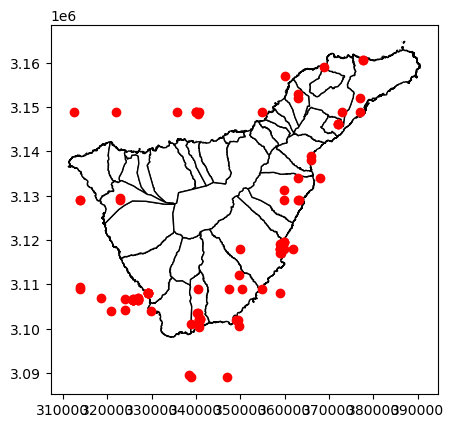

In [28]:
ax = muni_tenerife.plot(edgecolor="black", facecolor="white")

gdf.plot(ax=ax, color="red")  

In [29]:
## Gardamos como archivo shp
gdf.to_file(f"{ruta_demo_procesada}demo_tortugas_result_lugar.shp")

C:\Users\jcge9\AppData\Local\Temp\ipykernel_16116\3105453019.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(f"{ruta_demo_procesada}demo_tortugas_result_lugar.shp")
c:\Users\jcge9\miniconda3\envs\tortugas_pub\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'corrdenadas_utm' to 'corrdenada'
  ogr_write(


# Datasets procesados en [demo_datasets/demo_procesada/](../demo_datasets/demo_procesada/demo_tortugas_result.csv)